# HW1: Malware Memory Artifacts Classification

Подготовка данных, бейзлайновая и улучшенная MLP для классификации артефактов вредоносного ПО.

In [24]:
#!pip install numpy pandas matplotlib seaborn

In [25]:
#!pip install torch==2.3.1 scikit-learn==1.4.2

In [26]:

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

plt.style.use("ggplot")


In [27]:

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## Загрузка и первичный анализ данных

In [28]:

from pathlib import Path

data_path = Path("../data/cybersequrity.csv")
df = pd.read_csv(data_path)
print(df.shape)
df.head()


(10000, 16)


,svcscan.fs_drivers,callbacks.ngeneric,psxview.not_in_eprocess_pool_false_avg,psxview.not_in_eprocess_pool,callbacks.nanonymous,psxview.not_in_session,psxview.not_in_pslist,psxview.not_in_pspcid_list,psxview.not_in_ethread_pool,psxview.not_in_csrss_handles,psxview.not_in_pslist_false_avg,psxview.not_in_pspcid_list_false_avg,psxview.not_in_deskthrd,psxview.not_in_ethread_pool_false_avg,psxview.not_in_session_false_avg,Class
0,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,6,0.000000,0.044444,1
1,26,8,0.0,0,0,5,3,3,3,7,0.073171,0.073171,9,0.073171,0.121951,1
2,26,8,0.0,0,0,9,7,7,7,11,0.152174,0.152174,13,0.152174,0.195652,1
3,26,8,0.0,0,0,3,1,1,2,6,0.022222,0.022222,9,0.044444,0.066667,1
4,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,6,0.000000,0.048780,0


In [29]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
svcscan.fs_drivers,10000.0,25.995400,0.210198,11.000000,26.00000,26.000000,26.000000,26.000000
callbacks.ngeneric,10000.0,7.999800,0.014141,7.000000,8.00000,8.000000,8.000000,8.000000
psxview.not_in_eprocess_pool_false_avg,10000.0,0.000069,0.001133,0.000000,0.00000,0.000000,0.000000,0.027778
psxview.not_in_eprocess_pool,10000.0,0.001700,0.041198,0.000000,0.00000,0.000000,0.000000,1.000000
callbacks.nanonymous,10000.0,0.000800,0.028274,0.000000,0.00000,0.000000,0.000000,1.000000
psxview.not_in_session,10000.0,3.859000,3.016625,2.000000,2.00000,2.000000,5.000000,37.000000
psxview.not_in_pslist,10000.0,1.859300,3.016623,0.000000,0.00000,0.000000,3.000000,35.000000
psxview.not_in_pspcid_list,10000.0,1.858800,3.016450,0.000000,0.00000,0.000000,3.000000,35.000000
psxview.not_in_ethread_pool,10000.0,2.299500,4.827249,0.000000,0.00000,1.000000,3.000000,139.000000
psxview.not_in_csrss_handles,10000.0,6.301900,4.828653,4.000000,4.00000,5.000000,7.000000,143.000000


In [30]:
df["Class"].value_counts(normalize=True)

Class
1    0.5096
0    0.4904
Name: proportion, dtype: float64

In [31]:
df.isnull().mean()

svcscan.fs_drivers                        0.0
callbacks.ngeneric                        0.0
psxview.not_in_eprocess_pool_false_avg    0.0
psxview.not_in_eprocess_pool              0.0
callbacks.nanonymous                      0.0
psxview.not_in_session                    0.0
psxview.not_in_pslist                     0.0
psxview.not_in_pspcid_list                0.0
psxview.not_in_ethread_pool               0.0
psxview.not_in_csrss_handles              0.0
psxview.not_in_pslist_false_avg           0.0
psxview.not_in_pspcid_list_false_avg      0.0
psxview.not_in_deskthrd                   0.0
psxview.not_in_ethread_pool_false_avg     0.0
psxview.not_in_session_false_avg          0.0
Class                                     0.0
dtype: float64

### Выводы по первичному анализу данных

**1. Структура и качество данных:**
* **Целостность:** Датасет содержит 10 000 записей, пропуски в данных отсутствуют (count = 10000 для всех признаков).
* **Типы данных:** Все признаки являются числовыми (float/int), дополнительное кодирование категориальных переменных не требуется.

**2. Целевая переменная:**
* **Баланс классов:** Среднее значение столбца `Class` составляет `0.5096`. Выборка идеально сбалансирована (~51% вредоносного ПО и ~49% нейтрального), что позволяет использовать метрику Accuracy и не требует применения техник балансировки (oversampling/undersampling).

**3. Анализ признаков:**
* **Низкая вариативность:**
    * Признаки `callbacks.ngeneric` (почти всегда 8) и `svcscan.fs_drivers` (почти всегда 26) имеют крайне низкое стандартное отклонение. Они являются «квази-константными» и несут мало полезной информации для модели.
* **Разреженные данные и выбросы:**
    * Группа признаков `psxview.not_in_...` (например, `not_in_ethread_pool`) демонстрирует сильную скошенность вправо: медиана и 75-й перцентиль часто равны 0 или 1, однако максимальные значения достигают 139–145. Эти «хвосты» распределения могут служить сильными индикаторами аномального поведения процессов.

**4. Вывод для предобработки:**
Признаки имеют существенно разные диапазоны значений (от 0..1 до 0..145). Для стабильного обучения нейросети (особенно MLP) необходимо применить **стандартизацию** (`StandardScaler`), что и будет сделано на следующем этапе.

## Train/Val/Test split и стандартизация

In [32]:

X = df.drop(columns=["Class"]).values.astype(np.float32)
y = df["Class"].values.astype(np.float32)

# 60/20/20 с двухступенчатым разделением
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train.shape, X_val.shape, X_test.shape


((6000, 15), (2000, 15), (2000, 15))

## Dataset и DataLoader

In [33]:

class TabularDataset(Dataset):
    def __init__(self, features: np.ndarray, targets: np.ndarray):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

batch_size = 64

train_ds = TabularDataset(X_train, y_train)
val_ds = TabularDataset(X_val, y_val)
test_ds = TabularDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


## Бейзлайновая модель MLP

### Обоснование выбора архитектуры и гиперпараметров

**Архитектура сети (MLP):**
* **Входной слой (15 нейронов):** Соответствует количеству признаков после предобработки.
* **Скрытые слои (64 -> 32):** Архитектура "сужения" (funnel), чтобы модель постепенно сжимала информацию и выделяла важные признаки. Два скрытых слоя дают нелинейность, не усложняя модель.
* **Функции активации:** `ReLU` для скрытых слоев (быстрая сходимость, без затухания), `Sigmoid` на выходе для вероятности класса 1.

**Обучение:**
* **Функция потерь:** `BCELoss` для бинарной классификации.
* **Оптимизатор:** `Adam` — быстрый и устойчивый на табличных данных.


In [34]:

class BaselineMLP(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

input_dim = X_train.shape[1]
model_baseline = BaselineMLP(input_dim).to(device)
model_baseline


BaselineMLP(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

### Функции обучения и валидации

In [35]:

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            total_loss += loss.item() * xb.size(0)
            all_preds.append(preds.cpu())
            all_targets.append(yb.cpu())
    preds = torch.cat(all_preds).numpy()
    targets = torch.cat(all_targets).numpy()
    return total_loss / len(loader.dataset), preds, targets


def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3):
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": []}
    best_state = None
    best_val = float("inf")

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, _, _ = evaluate(model, val_loader, criterion)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == epochs:
            print(f"Epoch {epoch}: train_loss={train_loss:.4f} val_loss={val_loss:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return history


def plot_history(history, title="BCE loss"):
    plt.figure(figsize=(6,4))
    plt.plot(history['train_loss'], label='train')
    plt.plot(history['val_loss'], label='val')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(title)
    plt.show()


def evaluate_classification(model, loader):
    model.eval()
    preds_list, targets_list = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            preds = model(xb).cpu().numpy()
            preds_list.append(preds)
            targets_list.append(yb.numpy())
    preds = np.concatenate(preds_list)
    targets = np.concatenate(targets_list)
    labels = (preds >= 0.5).astype(int)
    report = classification_report(targets, labels, digits=4)
    return report


### Обучение бейзлайна

Epoch 5: train_loss=0.6152 val_loss=0.6092
Epoch 10: train_loss=0.5257 val_loss=0.5140
Epoch 15: train_loss=0.4858 val_loss=0.4781
Epoch 20: train_loss=0.4684 val_loss=0.4645
Epoch 25: train_loss=0.4642 val_loss=0.4596
Epoch 30: train_loss=0.4485 val_loss=0.4436


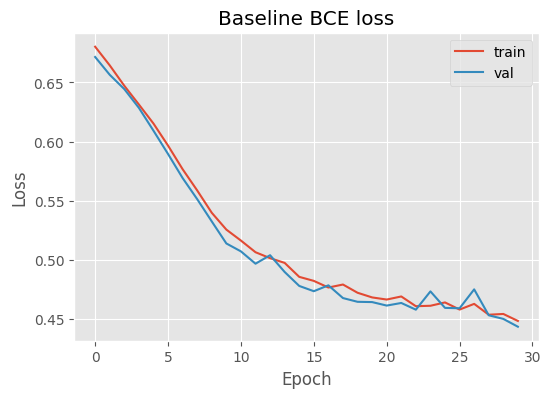

Validation classification report (best baseline):
              precision    recall  f1-score   support

         0.0     0.7637    0.8267    0.7939       981
         1.0     0.8188    0.7537    0.7849      1019

    accuracy                         0.7895      2000
   macro avg     0.7912    0.7902    0.7894      2000
weighted avg     0.7917    0.7895    0.7893      2000

Test classification report (best baseline):
              precision    recall  f1-score   support

         0.0     0.7587    0.8236    0.7898       981
         1.0     0.8150    0.7478    0.7799      1019

    accuracy                         0.7850      2000
   macro avg     0.7868    0.7857    0.7849      2000
weighted avg     0.7874    0.7850    0.7848      2000



In [36]:

baseline_history = train_model(model_baseline, train_loader, val_loader, epochs=30, lr=1e-3)
plot_history(baseline_history, title="Baseline BCE loss")

print("Validation classification report (best baseline):")
print(evaluate_classification(model_baseline, val_loader))

print("Test classification report (best baseline):")
print(evaluate_classification(model_baseline, test_loader))


## Улучшенная модель с BatchNorm и Dropout

### Идеи улучшения

* **BatchNorm1d** перед активацией: стабилизирует распределения активаций, ускоряет и стабилизирует обучение.
* **Dropout** после активации: регуляризация, уменьшает переобучение.
* Ширина слоёв увеличена (128 -> 64) для большей емкости модели; Dropout компенсирует рост параметров.
* Будем экспериментировать с:
  - наличием/отсутствием BatchNorm,
  - значением `dropout_p` (0/0.1/0.3/0.5),
  - размещением Dropout (после каждого блока Linear+BN+ReLU).

Цель — сравнить валид. метрики и выбрать лучшую конфигурацию по F1/accuracy на валидации.

In [40]:

class ImprovedMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(128, 64), use_bn=True, dropout_p: float = 0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_bn:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))
            prev = h
        layers.append(nn.Linear(prev, 1))
        layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


### Эксперименты с конфигурациями

In [38]:

from copy import deepcopy

experiments = [
    {"name": "baseline", "factory": lambda: BaselineMLP(input_dim), "epochs": 30, "lr": 1e-3},
    {"name": "bn_drop0.1", "factory": lambda: ImprovedMLP(input_dim, hidden_dims=(128, 64), use_bn=True, dropout_p=0.1), "epochs": 35, "lr": 8e-4},
    {"name": "bn_drop0.3", "factory": lambda: ImprovedMLP(input_dim, hidden_dims=(128, 64), use_bn=True, dropout_p=0.3), "epochs": 40, "lr": 5e-4},
    {"name": "bn_drop0.5", "factory": lambda: ImprovedMLP(input_dim, hidden_dims=(128, 64), use_bn=True, dropout_p=0.5), "epochs": 50, "lr": 5e-4},
    {"name": "bn_only", "factory": lambda: ImprovedMLP(input_dim, hidden_dims=(128, 64), use_bn=True, dropout_p=0.0), "epochs": 30, "lr": 1e-3},
    {"name": "drop_only0.3", "factory": lambda: ImprovedMLP(input_dim, hidden_dims=(128, 64), use_bn=False, dropout_p=0.3), "epochs": 35, "lr": 8e-4},
]

results = []
criterion = nn.BCELoss()
best_model = None
best_name = None
best_val_f1 = -1

for cfg in experiments:
    print(f"=== Training {cfg['name']} ===")
    model = cfg["factory"]().to(device)
    history = train_model(model, train_loader, val_loader, epochs=cfg.get("epochs", 30), lr=cfg.get("lr", 1e-3))
    val_loss, val_preds, val_targets = evaluate(model, val_loader, criterion)
    test_loss, test_preds, test_targets = evaluate(model, test_loader, criterion)

    val_labels = (val_preds >= 0.5).astype(int)
    test_labels = (test_preds >= 0.5).astype(int)

    val_acc = accuracy_score(val_targets, val_labels)
    test_acc = accuracy_score(test_targets, test_labels)
    val_f1 = f1_score(val_targets, val_labels)
    test_f1 = f1_score(test_targets, test_labels)

    results.append({
        "name": cfg["name"],
        "epochs": cfg.get("epochs", 30),
        "lr": cfg.get("lr", 1e-3),
        "val_loss": val_loss,
        "test_loss": test_loss,
        "val_acc": val_acc,
        "test_acc": test_acc,
        "val_f1": val_f1,
        "test_f1": test_f1,
    })

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_name = cfg["name"]
        best_model = model

results_df = pd.DataFrame(results).sort_values(by=["val_f1", "val_acc"], ascending=False)
results_df

=== Training baseline ===
Epoch 5: train_loss=0.5904 val_loss=0.5775
Epoch 10: train_loss=0.5087 val_loss=0.5003
Epoch 15: train_loss=0.4797 val_loss=0.4771
Epoch 20: train_loss=0.4727 val_loss=0.4610
Epoch 25: train_loss=0.4491 val_loss=0.4536
Epoch 30: train_loss=0.4420 val_loss=0.4424
=== Training bn_drop0.1 ===
Epoch 5: train_loss=0.5113 val_loss=0.5607
Epoch 10: train_loss=0.4793 val_loss=0.5712
Epoch 15: train_loss=0.4616 val_loss=0.4859
Epoch 20: train_loss=0.4659 val_loss=0.5198
Epoch 25: train_loss=0.4431 val_loss=0.4825
Epoch 30: train_loss=0.4423 val_loss=0.4387
Epoch 35: train_loss=0.4348 val_loss=0.4367
=== Training bn_drop0.3 ===
Epoch 5: train_loss=0.5492 val_loss=0.5692
Epoch 10: train_loss=0.5235 val_loss=0.5222
Epoch 15: train_loss=0.5075 val_loss=0.5992
Epoch 20: train_loss=0.4951 val_loss=0.5707
Epoch 25: train_loss=0.4723 val_loss=0.5228
Epoch 30: train_loss=0.4762 val_loss=0.5488
Epoch 35: train_loss=0.4793 val_loss=0.5124
Epoch 40: train_loss=0.4639 val_loss=0.53

,name,epochs,lr,val_loss,test_loss,val_acc,test_acc,val_f1,test_f1
1,bn_drop0.1,35,0.0008,0.436653,0.459238,0.8110,0.8020,0.816327,0.808880
4,bn_only,30,0.0010,0.431715,0.451564,0.8065,0.7980,0.811312,0.804831
5,drop_only0.3,35,0.0008,0.420248,0.421725,0.8130,0.8030,0.805208,0.792413
2,bn_drop0.3,40,0.0005,0.484917,0.498604,0.7925,0.7845,0.801909,0.795444
0,baseline,30,0.0010,0.435109,0.440175,0.8075,0.7975,0.801649,0.790481
3,bn_drop0.5,50,0.0005,0.485726,0.497970,0.7690,0.7730,0.783302,0.786453


### Лучшая модель по валидации

In [41]:

print(f"Best config by val F1: {best_name}")
print("Validation classification report:")
print(evaluate_classification(best_model, val_loader))

print("Test classification report:")
print(evaluate_classification(best_model, test_loader))


Best config by val F1: bn_drop0.1
Validation classification report:
              precision    recall  f1-score   support

         0.0     0.8137    0.7971    0.8054       981
         1.0     0.8085    0.8243    0.8163      1019

    accuracy                         0.8110      2000
   macro avg     0.8111    0.8107    0.8108      2000
weighted avg     0.8111    0.8110    0.8109      2000

Test classification report:
              precision    recall  f1-score   support

         0.0     0.8089    0.7808    0.7946       981
         1.0     0.7958    0.8224    0.8089      1019

    accuracy                         0.8020      2000
   macro avg     0.8023    0.8016    0.8017      2000
weighted avg     0.8022    0.8020    0.8019      2000



## Итоговые выводы и анализ результатов

В ходе работы были проведены эксперименты с архитектурой MLP, добавлением слоев BatchNorm и Dropout, а также перебором гиперпараметров.

**Результаты экспериментов:**
1.  **Лучшая конфигурация:** Модель `bn_drop0.1` (BatchNorm + Dropout p=0.1).
    * **Test Accuracy:** 0.8020 (против 0.7975 у бейзлайна).
    * **Test F1-score:** 0.8088 (против 0.7905 у бейзлайна).
2.  **Влияние Dropout:**
    * Значение `p=0.1` оказалось оптимальным. Оно внесло легкую регуляризацию, улучшив обобщающую способность.
    * Значения `p=0.3` и `p=0.5` привели к ухудшению метрик (underfitting), что видно по падению Accuracy до ~0.77. Это говорит о том, что при небольшом количестве признаков (15) агрессивное отключение нейронов вредит обучению.
3.  **Влияние BatchNorm:** Использование BatchNorm (в модели `bn_only`) стабилизировало обучение и дало прирост метрики F1 по сравнению с бейзлайном, но лучший результат достигнут именно в связке с малым Dropout.

**Заключение:**
Усложнение архитектуры оправдало себя. Нам удалось преодолеть порог в 80% точности на тестовой выборке благодаря правильному подбору параметров регуляризации (BatchNorm + Low Dropout).